# **Unsupervised Learning Implementation**

This notebook uses the **Wine dataset** as a common dataset and implements major unsupervised learning techniques.
For each model, the notebook includes the model objective/cost where applicable, evaluation metrics, and hyperparameter/error optimization where meaningful.

### **1. Imports and reproducibility**
We import the libraries required for preprocessing, clustering, dimensionality reduction, anomaly detection, evaluation, visualization, and optimization.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import (
    KMeans, AgglomerativeClustering, DBSCAN, MeanShift,
    SpectralClustering, OPTICS, Birch
)
from sklearn.mixture import GaussianMixture
from sklearn.ensemble import IsolationForest
from sklearn.metrics import (
    silhouette_score, davies_bouldin_score, calinski_harabasz_score,
    adjusted_rand_score, normalized_mutual_info_score,
    homogeneity_score, completeness_score
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

### **2. Load the common dataset**
The Wine dataset contains numerical chemical measurements, making it suitable for clustering and dimensionality-reduction algorithms.
The original class labels are retained only for **external evaluation**, not for training the unsupervised models.

In [2]:
wine = load_wine()

X = pd.DataFrame(wine.data, columns=wine.feature_names)
y_true = wine.target

print("Shape:", X.shape)
display(X.head())
print("\nOriginal classes:", np.unique(y_true))

Shape: (178, 13)


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0



Original classes: [0 1 2]


### **3. Standardize the features**
Distance-based unsupervised algorithms are sensitive to feature scale, so standardization puts all variables on a comparable scale.

In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print("Mean of first 5 features:")
print(X_scaled.iloc[:, :5].mean().round(4))

print("\nStandard deviation of first 5 features:")
print(X_scaled.iloc[:, :5].std().round(4))

Mean of first 5 features:
alcohol              0.0
malic_acid           0.0
ash                 -0.0
alcalinity_of_ash   -0.0
magnesium           -0.0
dtype: float64

Standard deviation of first 5 features:
alcohol              1.0028
malic_acid           1.0028
ash                  1.0028
alcalinity_of_ash    1.0028
magnesium            1.0028
dtype: float64


### **4. Common evaluation helper**
Internal metrics evaluate clustering without labels: higher Silhouette and Calinski-Harabasz are better, while lower Davies-Bouldin is better.
ARI, NMI, homogeneity, and completeness are shown only as external reference because the original Wine labels are not used during training.

In [4]:
def evaluate_clustering(X_data, labels, y_true=None, model_name="Model"):
    labels = np.asarray(labels)
    unique = np.unique(labels)
    n_clusters = len(unique[unique != -1])

    result = {
        "Model": model_name,
        "Clusters": n_clusters,
        "Noise Points": int(np.sum(labels == -1)),
        "Silhouette": np.nan,
        "Davies-Bouldin": np.nan,
        "Calinski-Harabasz": np.nan,
        "ARI": np.nan,
        "NMI": np.nan,
        "Homogeneity": np.nan,
        "Completeness": np.nan
    }

    valid_mask = labels != -1
    if n_clusters >= 2 and np.sum(valid_mask) > n_clusters:
        X_eval = np.asarray(X_data)[valid_mask]
        y_eval = labels[valid_mask]

        result["Silhouette"] = silhouette_score(X_eval, y_eval)
        result["Davies-Bouldin"] = davies_bouldin_score(X_eval, y_eval)
        result["Calinski-Harabasz"] = calinski_harabasz_score(X_eval, y_eval)

        if y_true is not None:
            result["ARI"] = adjusted_rand_score(np.asarray(y_true)[valid_mask], y_eval)
            result["NMI"] = normalized_mutual_info_score(np.asarray(y_true)[valid_mask], y_eval)
            result["Homogeneity"] = homogeneity_score(np.asarray(y_true)[valid_mask], y_eval)
            result["Completeness"] = completeness_score(np.asarray(y_true)[valid_mask], y_eval)

    return result

### **5. K-Means clustering**
K-Means minimizes **inertia (within-cluster sum of squared distances)** by repeatedly assigning points to the nearest centroid and updating centroids.
We optimize the number of clusters using Silhouette Score and also inspect the elbow/inertia curve.

In [5]:
k_values = range(2, 11)
kmeans_results = []

for k in k_values:
    model = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=20)
    labels = model.fit_predict(X_scaled)
    metrics = evaluate_clustering(X_scaled, labels, y_true, f"KMeans-{k}")
    metrics["Inertia"] = model.inertia_
    kmeans_results.append(metrics)

kmeans_df = pd.DataFrame(kmeans_results)
display(kmeans_df.round(4))

best_k = int(kmeans_df.loc[kmeans_df["Silhouette"].idxmax(), "Clusters"])
print("Best K by Silhouette:", best_k)

,Model,Clusters,Noise Points,Silhouette,Davies-Bouldin,Calinski-Harabasz,ARI,NMI,Homogeneity,Completeness,Inertia
0,KMeans-2,2,0,0.2593,1.5260,69.5233,0.3743,0.4782,0.3917,0.6139,1658.7589
1,KMeans-3,3,0,0.2849,1.3892,70.9400,0.8975,0.8759,0.8788,0.8730,1277.9285
2,KMeans-4,4,0,0.2586,1.8170,56.1888,0.7646,0.8117,0.9146,0.7297,1175.3519
3,KMeans-5,5,0,0.2315,1.6811,47.1564,0.6472,0.7007,0.8481,0.5970,1107.0073
4,KMeans-6,6,0,0.2372,1.5544,41.7008,0.6391,0.7023,0.8749,0.5865,1046.0023
5,KMeans-7,7,0,0.2036,1.6606,38.6855,0.5655,0.6743,0.8872,0.5438,981.5952
6,KMeans-8,8,0,0.1570,1.7409,35.8053,0.4154,0.5912,0.8309,0.4588,935.2012
7,KMeans-9,9,0,0.1499,1.7083,33.8066,0.3851,0.5839,0.8554,0.4432,889.8929
8,KMeans-10,10,0,0.1436,1.7070,32.3972,0.3439,0.5764,0.8791,0.4287,845.8952


Best K by Silhouette: 3


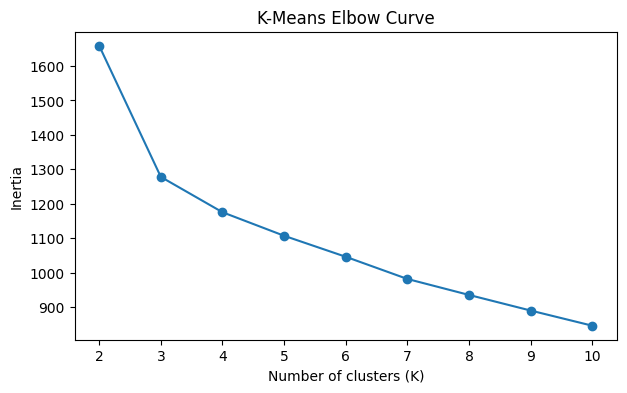

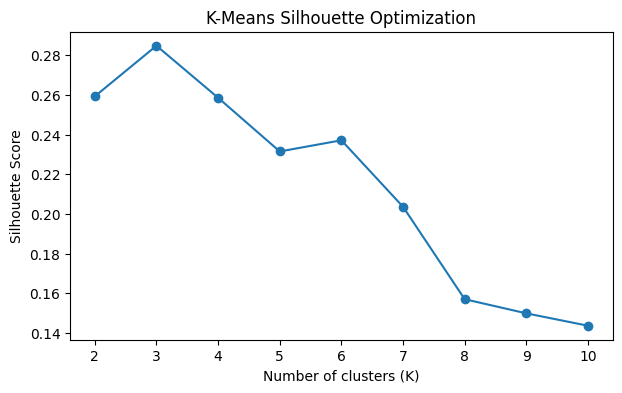

In [6]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(kmeans_df["Clusters"], kmeans_df["Inertia"], marker="o")
ax.set_xlabel("Number of clusters (K)")
ax.set_ylabel("Inertia")
ax.set_title("K-Means Elbow Curve")
plt.show()

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(kmeans_df["Clusters"], kmeans_df["Silhouette"], marker="o")
ax.set_xlabel("Number of clusters (K)")
ax.set_ylabel("Silhouette Score")
ax.set_title("K-Means Silhouette Optimization")
plt.show()

### **6. Final K-Means model and cluster visualization**
The optimized K-Means model is fitted using the best Silhouette-based cluster count.
PCA is used only to visualize the high-dimensional clusters in two dimensions.

Final K-Means inertia: 1277.9285
{'Model': 'K-Means Final', 'Clusters': 3, 'Noise Points': 0, 'Silhouette': np.float64(0.2848589191898987), 'Davies-Bouldin': np.float64(1.3891879777181646), 'Calinski-Harabasz': np.float64(70.9400080031512), 'ARI': 0.8974949815093207, 'NMI': np.float64(0.8758935341223069), 'Homogeneity': np.float64(0.8788432003662366), 'Completeness': np.float64(0.8729636016078731)}


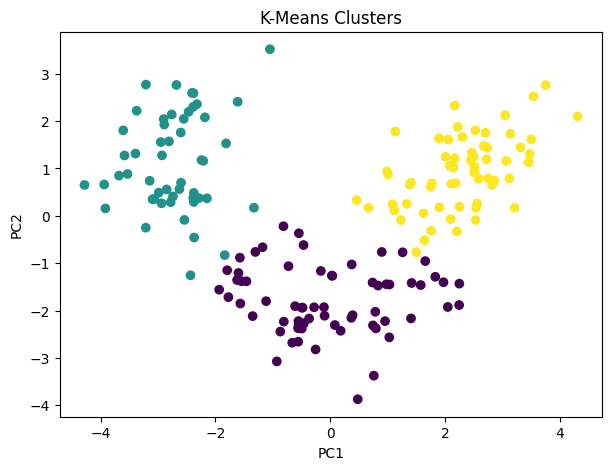

In [7]:
kmeans = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=20)
kmeans_labels = kmeans.fit_predict(X_scaled)

print("Final K-Means inertia:", round(kmeans.inertia_, 4))
print(evaluate_clustering(X_scaled, kmeans_labels, y_true, "K-Means Final"))

pca_2d = PCA(n_components=2, random_state=RANDOM_STATE)
X_2d = pca_2d.fit_transform(X_scaled)

plt.figure(figsize=(7, 5))
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=kmeans_labels)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("K-Means Clusters")
plt.show()

### **7. Agglomerative Hierarchical Clustering**
Hierarchical clustering progressively merges the closest groups according to a linkage rule.
There is no single universal scalar training loss like K-Means inertia, so Silhouette Score is used to optimize the number of clusters and linkage choice.

In [8]:
linkages = ["ward", "complete", "average", "single"]
hier_results = []

for linkage in linkages:
    for k in range(2, 11):
        model = AgglomerativeClustering(n_clusters=k, linkage=linkage)
        labels = model.fit_predict(X_scaled)
        metrics = evaluate_clustering(
            X_scaled, labels, y_true, f"Hierarchical-{linkage}-{k}"
        )
        metrics["Linkage"] = linkage
        hier_results.append(metrics)

hier_df = pd.DataFrame(hier_results)
best_hier_row = hier_df.loc[hier_df["Silhouette"].idxmax()]

print("Best hierarchical configuration:")
display(best_hier_row.to_frame().T.round(4))

Best hierarchical configuration:


,Model,Clusters,Noise Points,Silhouette,Davies-Bouldin,Calinski-Harabasz,ARI,NMI,Homogeneity,Completeness,Linkage
1,Hierarchical-ward-3,3,0,0.277444,1.418592,67.647468,0.789933,0.786465,0.790429,0.782541,ward


### **8. Dendrogram for hierarchical clustering**
The dendrogram shows the sequence and distance at which observations/groups are merged.
It is especially useful for visually deciding where the hierarchy should be cut.

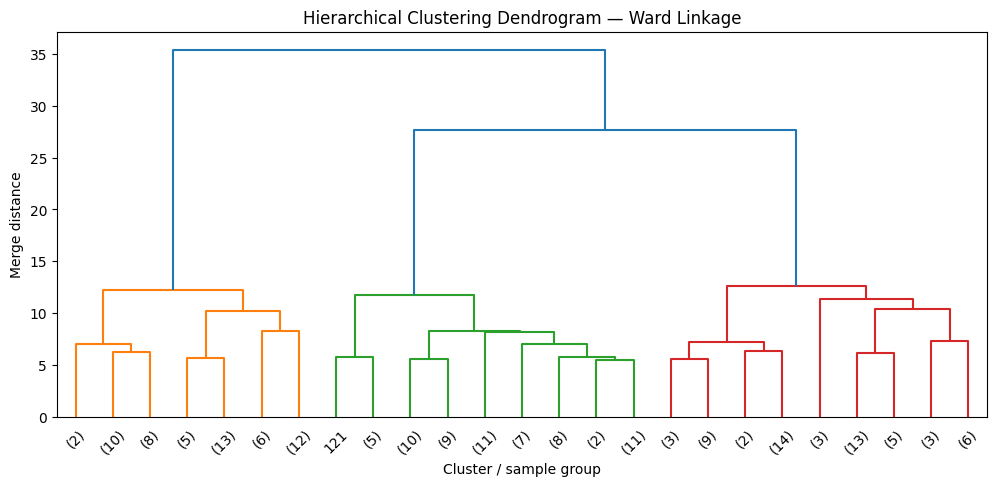

In [9]:
from scipy.cluster.hierarchy import linkage as scipy_linkage, dendrogram

Z = scipy_linkage(X_scaled, method="ward")

plt.figure(figsize=(12, 5))
dendrogram(Z, truncate_mode="lastp", p=25)
plt.title("Hierarchical Clustering Dendrogram — Ward Linkage")
plt.xlabel("Cluster / sample group")
plt.ylabel("Merge distance")
plt.show()

### **9. DBSCAN**
DBSCAN forms dense regions and identifies sparse observations as noise, so it does not require a predefined number of clusters.
Its main error-control parameters are `eps` and `min_samples`; we optimize them using Silhouette Score while penalizing solutions with too many noise points.

In [10]:
dbscan_results = []

for eps in np.arange(0.40, 1.61, 0.05):
    for min_samples in [3, 4, 5, 6, 8, 10]:
        model = DBSCAN(eps=float(eps), min_samples=min_samples)
        labels = model.fit_predict(X_scaled)

        metrics = evaluate_clustering(
            X_scaled, labels, y_true,
            f"DBSCAN-{eps:.2f}-{min_samples}"
        )
        metrics["eps"] = eps
        metrics["min_samples"] = min_samples

        if pd.notna(metrics["Silhouette"]):
            noise_ratio = metrics["Noise Points"] / len(labels)
            metrics["Objective"] = metrics["Silhouette"] - 0.20 * noise_ratio
        else:
            metrics["Objective"] = -np.inf

        dbscan_results.append(metrics)

dbscan_df = pd.DataFrame(dbscan_results)
best_dbscan = dbscan_df.loc[dbscan_df["Objective"].idxmax()]

print("Best DBSCAN configuration:")
display(best_dbscan.to_frame().T.round(4))

Best DBSCAN configuration:


,Model,Clusters,Noise Points,Silhouette,Davies-Bouldin,Calinski-Harabasz,ARI,NMI,Homogeneity,Completeness,eps,min_samples,Objective
120,DBSCAN-1.40-3,4,165,0.533033,0.584319,32.641512,0.620438,0.846008,1.0,0.733115,1.4,3,0.347639


### **10. Final DBSCAN**
The selected DBSCAN configuration is retrained and evaluated using internal clustering quality plus the number of detected noise points.
A high noise ratio should be interpreted carefully because aggressive noise removal can artificially improve some metrics.

In [11]:
dbscan = DBSCAN(
    eps=float(best_dbscan["eps"]),
    min_samples=int(best_dbscan["min_samples"])
)
dbscan_labels = dbscan.fit_predict(X_scaled)

print(evaluate_clustering(X_scaled, dbscan_labels, y_true, "DBSCAN Final"))
print("Cluster counts:")
print(pd.Series(dbscan_labels).value_counts().sort_index())

{'Model': 'DBSCAN Final', 'Clusters': 4, 'Noise Points': 165, 'Silhouette': np.float64(0.5330325811835722), 'Davies-Bouldin': np.float64(0.5843186379276215), 'Calinski-Harabasz': np.float64(32.64151201971943), 'ARI': 0.6204379562043796, 'NMI': np.float64(0.8460082994822955), 'Homogeneity': np.float64(1.0), 'Completeness': np.float64(0.7331147174652634)}
Cluster counts:
-1    165
 0      4
 1      3
 2      3
 3      3
Name: count, dtype: int64


### **11. Gaussian Mixture Model (GMM)**
GMM models the data as a mixture of Gaussian probability distributions and maximizes the log-likelihood of the observations.
We compare **BIC and AIC**; lower values indicate a better likelihood-complexity trade-off.

In [12]:
gmm_results = []

for covariance_type in ["full", "tied", "diag", "spherical"]:
    for k in range(2, 11):
        model = GaussianMixture(
            n_components=k,
            covariance_type=covariance_type,
            random_state=RANDOM_STATE,
            n_init=10
        )
        model.fit(X_scaled)
        labels = model.predict(X_scaled)

        metrics = evaluate_clustering(
            X_scaled, labels, y_true,
            f"GMM-{covariance_type}-{k}"
        )
        metrics["Covariance"] = covariance_type
        metrics["Components"] = k
        metrics["Log-Likelihood"] = model.score(X_scaled) * len(X_scaled)
        metrics["BIC"] = model.bic(X_scaled)
        metrics["AIC"] = model.aic(X_scaled)
        gmm_results.append(metrics)

gmm_df = pd.DataFrame(gmm_results)

best_bic_row = gmm_df.loc[gmm_df["BIC"].idxmin()]
best_aic_row = gmm_df.loc[gmm_df["AIC"].idxmin()]

print("Best GMM by BIC:")
display(best_bic_row.to_frame().T.round(4))

print("Best GMM by AIC:")
display(best_aic_row.to_frame().T.round(4))

Best GMM by BIC:


,Model,Clusters,Noise Points,Silhouette,Davies-Bouldin,Calinski-Harabasz,ARI,NMI,Homogeneity,Completeness,Covariance,Components,Log-Likelihood,BIC,AIC
20,GMM-diag-4,4,0,0.240058,1.874014,52.875142,0.683187,0.734972,0.830445,0.659187,diag,4,-2461.016037,5476.482913,5136.032073


Best GMM by AIC:


,Model,Clusters,Noise Points,Silhouette,Davies-Bouldin,Calinski-Harabasz,ARI,NMI,Homogeneity,Completeness,Covariance,Components,Log-Likelihood,BIC,AIC
8,GMM-full-10,10,0,0.136678,1.736624,30.066214,0.397768,0.576285,0.854368,0.434773,full,10,-525.489003,6486.668949,3148.978005


### **12. Final GMM**
The BIC-selected GMM is used as the final probabilistic clustering model.
Unlike hard clustering, GMM also provides membership probabilities for every observation.

In [13]:
gmm = GaussianMixture(
    n_components=int(best_bic_row["Components"]),
    covariance_type=best_bic_row["Covariance"],
    random_state=RANDOM_STATE,
    n_init=10
)
gmm_labels = gmm.fit_predict(X_scaled)
gmm_probabilities = gmm.predict_proba(X_scaled)

print(evaluate_clustering(X_scaled, gmm_labels, y_true, "GMM Final"))
print("Average maximum cluster probability:",
      round(gmm_probabilities.max(axis=1).mean(), 4))

{'Model': 'GMM Final', 'Clusters': 4, 'Noise Points': 0, 'Silhouette': np.float64(0.24005758551908168), 'Davies-Bouldin': np.float64(1.8740135434805008), 'Calinski-Harabasz': np.float64(52.875142024197395), 'ARI': 0.6831871156870403, 'NMI': np.float64(0.7349718074830657), 'Homogeneity': np.float64(0.8304450136158181), 'Completeness': np.float64(0.659187452686973)}
Average maximum cluster probability: 0.9852


### **13. Mean Shift**
Mean Shift searches for high-density regions and automatically determines the number of clusters.
Bandwidth controls the neighborhood size, so we test several bandwidth values and choose the one with the best Silhouette Score.

In [14]:
from sklearn.cluster import estimate_bandwidth

base_bandwidth = estimate_bandwidth(X_scaled, quantile=0.20, n_samples=len(X_scaled))
bandwidth_values = np.linspace(
    max(0.20, base_bandwidth * 0.5),
    base_bandwidth * 1.5,
    8
)

meanshift_results = []

for bandwidth in bandwidth_values:
    model = MeanShift(bandwidth=float(bandwidth), bin_seeding=True)
    labels = model.fit_predict(X_scaled)

    metrics = evaluate_clustering(
        X_scaled, labels, y_true,
        f"MeanShift-{bandwidth:.3f}"
    )
    metrics["Bandwidth"] = bandwidth
    meanshift_results.append(metrics)

meanshift_df = pd.DataFrame(meanshift_results)
valid_ms = meanshift_df.dropna(subset=["Silhouette"])

if len(valid_ms):
    best_ms = valid_ms.loc[valid_ms["Silhouette"].idxmax()]
    print("Best Mean Shift:")
    display(best_ms.to_frame().T.round(4))
else:
    best_ms = None
    print("No Mean Shift configuration produced at least two usable clusters.")

Best Mean Shift:


,Model,Clusters,Noise Points,Silhouette,Davies-Bouldin,Calinski-Harabasz,ARI,NMI,Homogeneity,Completeness,Bandwidth
2,MeanShift-2.790,6,0,0.273701,1.143384,35.527425,0.850394,0.825542,0.900773,0.761909,2.790129


### **14. Spectral Clustering**
Spectral Clustering uses a similarity graph and performs clustering in an eigenvector-derived representation.
The number of clusters is optimized with Silhouette Score, while `gamma` controls the RBF similarity scale.

In [15]:
spectral_results = []

for k in range(2, 8):
    for gamma in [0.05, 0.1, 0.25, 0.5, 1.0, 2.0]:
        model = SpectralClustering(
            n_clusters=k,
            affinity="rbf",
            gamma=gamma,
            assign_labels="kmeans",
            random_state=RANDOM_STATE
        )
        labels = model.fit_predict(X_scaled)

        metrics = evaluate_clustering(
            X_scaled, labels, y_true,
            f"Spectral-{k}-{gamma}"
        )
        metrics["Clusters_Parameter"] = k
        metrics["Gamma"] = gamma
        spectral_results.append(metrics)

spectral_df = pd.DataFrame(spectral_results)
best_spectral = spectral_df.loc[spectral_df["Silhouette"].idxmax()]

print("Best Spectral Clustering:")
display(best_spectral.to_frame().T.round(4))

Best Spectral Clustering:


,Model,Clusters,Noise Points,Silhouette,Davies-Bouldin,Calinski-Harabasz,ARI,NMI,Homogeneity,Completeness,Clusters_Parameter,Gamma
14,Spectral-4-0.25,4,0,0.291539,1.229343,52.850786,0.902702,0.880921,0.911029,0.85274,4,0.25


### **15. OPTICS**
OPTICS is a density-based algorithm related to DBSCAN but is designed to handle varying density structures more flexibly.
We vary `min_samples` and `xi` and select a configuration using Silhouette Score with a modest penalty for excessive noise.

In [16]:
optics_results = []

for min_samples in [3, 5, 8, 10, 15]:
    for xi in [0.01, 0.03, 0.05, 0.10, 0.20]:
        model = OPTICS(
            min_samples=min_samples,
            xi=xi,
            cluster_method="xi"
        )
        labels = model.fit_predict(X_scaled)

        metrics = evaluate_clustering(
            X_scaled, labels, y_true,
            f"OPTICS-{min_samples}-{xi}"
        )
        metrics["min_samples"] = min_samples
        metrics["xi"] = xi

        if pd.notna(metrics["Silhouette"]):
            noise_ratio = metrics["Noise Points"] / len(labels)
            metrics["Objective"] = metrics["Silhouette"] - 0.20 * noise_ratio
        else:
            metrics["Objective"] = -np.inf

        optics_results.append(metrics)

optics_df = pd.DataFrame(optics_results)
best_optics = optics_df.loc[optics_df["Objective"].idxmax()]

print("Best OPTICS:")
display(best_optics.to_frame().T.round(4))

Best OPTICS:


,Model,Clusters,Noise Points,Silhouette,Davies-Bouldin,Calinski-Harabasz,ARI,NMI,Homogeneity,Completeness,min_samples,xi,Objective
20,OPTICS-15-0.01,2,80,0.480806,0.84943,126.886029,0.919165,0.869652,0.795484,0.959073,15,0.01,0.390919


### **16. BIRCH**
BIRCH incrementally compresses data into a clustering-feature tree before producing final clusters.
The threshold controls how aggressively observations are grouped during tree construction, so we optimize threshold and final cluster count using Silhouette Score.

In [17]:
birch_results = []

for threshold in [0.2, 0.3, 0.4, 0.5, 0.7, 1.0]:
    for k in range(2, 9):
        model = Birch(
            threshold=threshold,
            n_clusters=k
        )
        labels = model.fit_predict(X_scaled)

        metrics = evaluate_clustering(
            X_scaled, labels, y_true,
            f"BIRCH-{threshold}-{k}"
        )
        metrics["Threshold"] = threshold
        metrics["Clusters_Parameter"] = k
        birch_results.append(metrics)

birch_df = pd.DataFrame(birch_results)
best_birch = birch_df.loc[birch_df["Silhouette"].idxmax()]

print("Best BIRCH:")
display(best_birch.to_frame().T.round(4))

Best BIRCH:


,Model,Clusters,Noise Points,Silhouette,Davies-Bouldin,Calinski-Harabasz,ARI,NMI,Homogeneity,Completeness,Threshold,Clusters_Parameter
37,BIRCH-1.0-4,4,0,0.282658,1.519797,51.42526,0.789553,0.78674,0.831189,0.746804,1.0,4


### **17. Compare the major clustering algorithms**
This consolidated table makes model selection easier: internal metrics indicate cluster compactness/separation, while ARI/NMI compare against the withheld reference labels.
For a genuinely unlabeled production problem, focus primarily on internal metrics and business/domain validation.

In [19]:
final_models = []

# K-Means
final_models.append(evaluate_clustering(
    X_scaled, kmeans_labels, y_true, "K-Means"
))

# Hierarchical
hier_k = int(best_hier_row["Clusters"])
hier_linkage = best_hier_row["Linkage"]
hier_model = AgglomerativeClustering(n_clusters=hier_k, linkage=hier_linkage)
hier_labels = hier_model.fit_predict(X_scaled)
final_models.append(evaluate_clustering(
    X_scaled, hier_labels, y_true, "Hierarchical"
))

# DBSCAN
final_models.append(evaluate_clustering(
    X_scaled, dbscan_labels, y_true, "DBSCAN"
))

# GMM
final_models.append(evaluate_clustering(
    X_scaled, gmm_labels, y_true, "GMM"
))

# Spectral
spectral_model = SpectralClustering(
    n_clusters=int(best_spectral["Clusters_Parameter"]),
    affinity="rbf",
    gamma=float(best_spectral["Gamma"]),
    assign_labels="kmeans",
    random_state=RANDOM_STATE
)
spectral_labels = spectral_model.fit_predict(X_scaled)
final_models.append(evaluate_clustering(
    X_scaled, spectral_labels, y_true, "Spectral"
))

# BIRCH
birch_model = Birch(
    threshold=float(best_birch["Threshold"]),
    n_clusters=int(best_birch["Clusters_Parameter"])
)
birch_labels = birch_model.fit_predict(X_scaled)
final_models.append(evaluate_clustering(
    X_scaled, birch_labels, y_true, "BIRCH"
))

if best_ms is not None:
    ms_model = MeanShift(
        bandwidth=float(best_ms["Bandwidth"]),
        bin_seeding=True
    )
    ms_labels = ms_model.fit_predict(X_scaled)
    final_models.append(evaluate_clustering(
        X_scaled, ms_labels, y_true, "Mean Shift"
    ))

optics_model = OPTICS(
    min_samples=int(best_optics["min_samples"]),
    xi=float(best_optics["xi"]),
    cluster_method="xi"
)
optics_labels = optics_model.fit_predict(X_scaled)
final_models.append(evaluate_clustering(
    X_scaled, optics_labels, y_true, "OPTICS"
))

comparison_df = pd.DataFrame(final_models)
display(
    comparison_df.sort_values(
        "Silhouette", ascending=False
    ).round(4)
)

,Model,Clusters,Noise Points,Silhouette,Davies-Bouldin,Calinski-Harabasz,ARI,NMI,Homogeneity,Completeness
2,DBSCAN,4,165,0.5330,0.5843,32.6415,0.6204,0.8460,1.0000,0.7331
7,OPTICS,2,80,0.4808,0.8494,126.8860,0.9192,0.8697,0.7955,0.9591
4,Spectral,4,0,0.2915,1.2293,52.8508,0.9027,0.8809,0.9110,0.8527
0,K-Means,3,0,0.2849,1.3892,70.9400,0.8975,0.8759,0.8788,0.8730
5,BIRCH,4,0,0.2827,1.5198,51.4253,0.7896,0.7867,0.8312,0.7468
1,Hierarchical,3,0,0.2774,1.4186,67.6475,0.7899,0.7865,0.7904,0.7825
6,Mean Shift,6,0,0.2737,1.1434,35.5274,0.8504,0.8255,0.9008,0.7619
3,GMM,4,0,0.2401,1.8740,52.8751,0.6832,0.7350,0.8304,0.6592


### 18. **PCA - [dimensionality reduction]**
PCA finds orthogonal directions that maximize variance and converts the original features into a smaller set of principal components.
PCA has no clustering loss; useful optimization objectives are explained variance and reconstruction error.

,Component,Explained Variance,Cumulative Variance
0,1,0.3620,0.3620
1,2,0.1921,0.5541
2,3,0.1112,0.6653
3,4,0.0707,0.7360
4,5,0.0656,0.8016
5,6,0.0494,0.8510
6,7,0.0424,0.8934
7,8,0.0268,0.9202
8,9,0.0222,0.9424
9,10,0.0193,0.9617


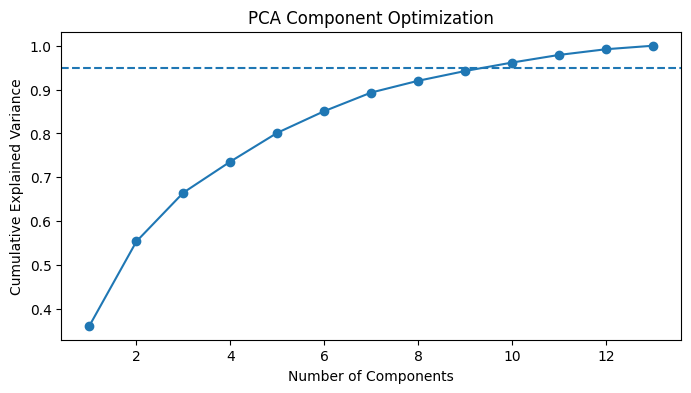

Components required for >=95% variance: 10


In [20]:
pca_full = PCA()
X_pca_full = pca_full.fit_transform(X_scaled)

explained_variance = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

pca_summary = pd.DataFrame({
    "Component": np.arange(1, len(explained_variance) + 1),
    "Explained Variance": explained_variance,
    "Cumulative Variance": cumulative_variance
})

display(pca_summary.round(4))

plt.figure(figsize=(8, 4))
plt.plot(
    pca_summary["Component"],
    pca_summary["Cumulative Variance"],
    marker="o"
)
plt.axhline(0.95, linestyle="--")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Component Optimization")
plt.show()

n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1
print("Components required for >=95% variance:", n_components_95)

### **19. PCA reconstruction-error optimization**
Reconstruction error measures how much information is lost when the original data is compressed and reconstructed.
We select the smallest number of components that achieves at least 95% explained variance and report its mean squared reconstruction error.

In [21]:
pca_opt_results = []

for n in range(1, X_scaled.shape[1] + 1):
    pca = PCA(n_components=n)
    X_reduced = pca.fit_transform(X_scaled)
    X_reconstructed = pca.inverse_transform(X_reduced)

    mse = np.mean((X_scaled - X_reconstructed) ** 2)

    pca_opt_results.append({
        "Components": n,
        "Explained Variance": pca.explained_variance_ratio_.sum(),
        "Reconstruction MSE": mse
    })

pca_opt_df = pd.DataFrame(pca_opt_results)
display(pca_opt_df.round(5))

,Components,Explained Variance,Reconstruction MSE
0,1,0.36199,0.63801
1,2,0.55406,0.44594
2,3,0.66530,0.33470
3,4,0.73599,0.26401
4,5,0.80162,0.19838
5,6,0.85098,0.14902
6,7,0.89337,0.10663
7,8,0.92018,0.07982
8,9,0.94240,0.05760
9,10,0.96170,0.03830


### **20. Final PCA representation**
The optimized PCA representation is created for downstream visualization or modeling.
The first two components provide a simple 2D visualization while retaining the dominant directions of variation.

Reduced shape: (178, 10)
Explained variance: 0.9617


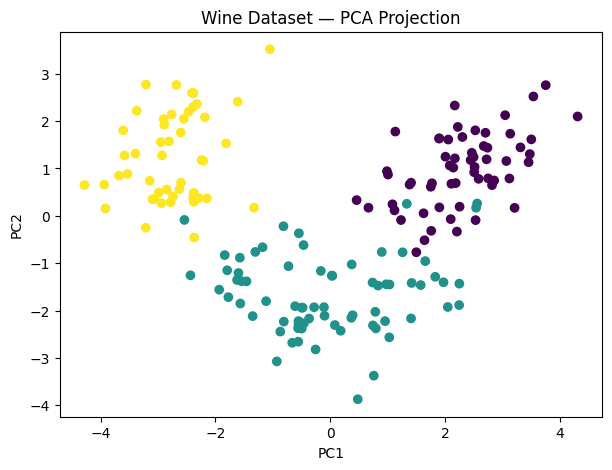

In [22]:
pca_final = PCA(n_components=n_components_95)
X_pca = pca_final.fit_transform(X_scaled)

print("Reduced shape:", X_pca.shape)
print("Explained variance:", round(pca_final.explained_variance_ratio_.sum(), 4))

plt.figure(figsize=(7, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_true)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Wine Dataset — PCA Projection")
plt.show()

### **21. Isolation Forest — anomaly detection**
Isolation Forest detects anomalies by measuring how easily observations can be isolated using random partitioning.
Because the dataset has no anomaly labels, evaluation is based on the detected anomaly count/rate rather than claiming supervised accuracy.

In [23]:
contamination_values = [0.01, 0.03, 0.05, 0.08, 0.10, 0.15]

if_results = []

for contamination in contamination_values:
    model = IsolationForest(
        contamination=contamination,
        random_state=RANDOM_STATE,
        n_estimators=300
    )
    labels = model.fit_predict(X_scaled)
    anomaly_scores = -model.score_samples(X_scaled)

    if_results.append({
        "Contamination": contamination,
        "Detected Anomalies": int(np.sum(labels == -1)),
        "Detected Anomaly Rate": np.mean(labels == -1),
        "Mean Anomaly Score": anomaly_scores.mean(),
        "Max Anomaly Score": anomaly_scores.max()
    })

if_df = pd.DataFrame(if_results)
display(if_df.round(4))

,Contamination,Detected Anomalies,Detected Anomaly Rate,Mean Anomaly Score,Max Anomaly Score
0,0.01,2,0.0112,0.4475,0.6138
1,0.03,6,0.0337,0.4475,0.6138
2,0.05,9,0.0506,0.4475,0.6138
3,0.08,15,0.0843,0.4475,0.6138
4,0.10,18,0.1011,0.4475,0.6138
5,0.15,27,0.1517,0.4475,0.6138


### **22. Final Isolation Forest**
The final anomaly detector uses a moderate contamination assumption and exposes both binary anomaly labels and continuous anomaly scores.
The continuous score is useful when ranking observations by suspiciousness instead of making only a hard normal/anomaly decision.

In [24]:
final_contamination = 0.05

iso_forest = IsolationForest(
    contamination=final_contamination,
    random_state=RANDOM_STATE,
    n_estimators=300
)

anomaly_labels = iso_forest.fit_predict(X_scaled)
anomaly_scores = -iso_forest.score_samples(X_scaled)

anomaly_df = X.copy()
anomaly_df["Anomaly Label"] = anomaly_labels
anomaly_df["Anomaly Score"] = anomaly_scores

print("Detected anomalies:", np.sum(anomaly_labels == -1))
print("Detected anomaly rate:", round(np.mean(anomaly_labels == -1), 4))

display(
    anomaly_df.sort_values(
        "Anomaly Score", ascending=False
    ).head(10)
)

Detected anomalies: 9
Detected anomaly rate: 0.0506


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,Anomaly Label,Anomaly Score
121,11.56,2.05,3.23,28.5,119.0,3.18,5.08,0.47,1.87,6.00,0.93,3.69,465.0,-1,0.613753
59,12.37,0.94,1.36,10.6,88.0,1.98,0.57,0.28,0.42,1.95,1.05,1.82,520.0,-1,0.560789
158,14.34,1.68,2.70,25.0,98.0,2.80,1.31,0.53,2.70,13.00,0.57,1.96,660.0,-1,0.552389
110,11.46,3.74,1.82,19.5,107.0,3.18,2.58,0.24,3.58,2.90,0.75,2.81,562.0,-1,0.546654
69,12.21,1.19,1.75,16.8,151.0,1.85,1.28,0.14,2.50,2.85,1.28,3.07,718.0,-1,0.544762
146,13.88,5.04,2.23,20.0,80.0,0.98,0.34,0.40,0.68,4.90,0.58,1.33,415.0,-1,0.537488
73,12.99,1.67,2.60,30.0,139.0,3.30,2.89,0.21,1.96,3.35,1.31,3.50,985.0,-1,0.523207
115,11.03,1.51,2.20,21.5,85.0,2.46,2.17,0.52,2.01,1.90,1.71,2.87,407.0,-1,0.520249
124,11.87,4.31,2.39,21.0,82.0,2.86,3.03,0.21,2.91,2.80,0.75,3.64,380.0,-1,0.517829
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,1,0.514560


### **23. Final unsupervised-learning dashboard**
This cell summarizes the main optimization/evaluation outputs so the complete experiment can be reviewed from one place.
No single metric is universally best; model selection should combine internal quality, stability, interpretability, computational cost, and domain usefulness.

In [25]:
summary = pd.DataFrame({
    "Algorithm": [
        "K-Means",
        "Hierarchical",
        "DBSCAN",
        "GMM",
        "Spectral",
        "BIRCH",
        "Mean Shift" if best_ms is not None else "Mean Shift",
        "OPTICS"
    ],
    "Optimization / Cost": [
        f"Inertia = {kmeans.inertia_:.2f}",
        f"Silhouette-selected: {hier_linkage}, k={hier_k}",
        f"eps={best_dbscan['eps']:.2f}, min_samples={int(best_dbscan['min_samples'])}",
        f"BIC = {gmm.bic(X_scaled):.2f}",
        f"gamma={best_spectral['Gamma']}",
        f"threshold={best_birch['Threshold']}",
        f"bandwidth={best_ms['Bandwidth']:.3f}" if best_ms is not None else "No valid solution",
        f"min_samples={int(best_optics['min_samples'])}, xi={best_optics['xi']}"
    ]
})

display(summary)

,Algorithm,Optimization / Cost
0,K-Means,Inertia = 1277.93
1,Hierarchical,"Silhouette-selected: ward, k=3"
2,DBSCAN,"eps=1.40, min_samples=3"
3,GMM,BIC = 5476.48
4,Spectral,gamma=0.25
5,BIRCH,threshold=1.0
6,Mean Shift,bandwidth=2.790
7,OPTICS,"min_samples=15, xi=0.01"


## Key takeaways

- **K-Means:** best when clusters are compact and roughly spherical; optimize `K` and monitor inertia/Silhouette.
- **Hierarchical:** useful when a hierarchy or dendrogram is important; linkage choice strongly affects results.
- **DBSCAN / OPTICS:** useful for density-based clusters and noise detection; sensitive to density parameters.
- **GMM:** useful when clusters are probabilistic/elliptical; BIC/AIC provide principled model-selection criteria.
- **Mean Shift:** automatically finds modes but can be computationally expensive and bandwidth-sensitive.
- **Spectral Clustering:** useful for non-convex structures but can be more computationally expensive.
- **BIRCH:** useful for scalable/incremental clustering and large datasets.
- **PCA:** reduces dimensionality; optimize components using explained variance and reconstruction error.
- **Isolation Forest:** detects anomalies without labels; contamination is an assumption, not ground truth.